In [54]:
###################################### src/as_model.py
import numpy as np

def calculate_spread(mid_price: float, inventory: float,
                    volatility: float, gamma: float = 0.1) -> tuple[float, float]:
    """Your original A-S implementation"""
    spread = gamma * (volatility ** 2) * (1 - (inventory ** 2))
    return (mid_price - spread / 2, mid_price + spread / 2)

In [55]:

def calculate_spread(mid_price, inventory, volatility, gamma=666.67):  # Gamma tuned for δ=20
    spread = gamma * (volatility ** 2) * (1 - (inventory ** 2))
    return (mid_price - spread / 2, mid_price + spread / 2)

bid, ask = calculate_spread(2000, 0.5, 0.2)  # Now gamma=666.67
print(f"Bid: {bid:.2f}, Ask: {ask:.2f}")      # Output: Bid: 1990.00, Ask: 2010.00

Bid: 1990.00, Ask: 2010.00


In [56]:
# Design the RL Environment
# src/env.py
import gym
import numpy as np

class TradingEnv(gym.Env):
    def __init__(self, data):
        self.data = data  # Your aligned CEX/on-chain data
        self.action_space = gym.spaces.Box(low=-1, high=1, shape=(2,))  # [bid_adj, ask_adj]
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(8,))  # 8 features

    def step(self, action):
        # 1. Get current state (price, vol, inventory, etc.)
        state = self._get_state()

        # 2. Apply action (adjust A-S spreads)
        new_bid = state['bid'] * (1 + action[0])
        new_ask = state['ask'] * (1 + action[1])

        # 3. Calculate reward (your MBA risk management)
        reward = self._calculate_pnl(new_bid, new_ask) - 0.5 * abs(state['inventory'])

        # 4. Update environment
        self.current_step += 1
        done = self.current_step >= len(self.data)

        return state, reward, done, {}

    def _get_state(self):
        """Your feature engineering skills here"""
        return {
            'price': self.data[self.current_step]['price'],
            'volatility': self.data[self.current_step]['vol'],
            'inventory': self.data[self.current_step]['inv'],
            # ... +5 more features
        }

In [9]:
!pip install python-binance web3 pandas numpy stable-baselines3 gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.3/130.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.5/587.5 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211

In [10]:
import pandas as pd
from binance.client import Client  # Now works!
import web3

/usr/local/lib/python3.11/dist-packages/binance/ws/websocket_api.py:4: DeprecationWarning: websockets.WebSocketClientProtocol is deprecated
  from websockets import WebSocketClientProtocol  # type: ignore
/usr/local/lib/python3.11/dist-packages/websockets/legacy/__init__.py:6: DeprecationWarning: websockets.legacy is deprecated; see https://websockets.readthedocs.io/en/stable/howto/upgrade.html for upgrade instructions
  warnings.warn(  # deprecated in 14.0 - 2024-11-09


In [57]:
loader = DataLoader(
    binance_api_key="YOUR_API_KEY",  # Get from Binance → API Management
    binance_secret="YOUR_SECRET_KEY",
    infura_url="https://mainnet.infura.io/v3/YOUR_INFURA_KEY"  # Or use a public RPC
)

In [58]:
from binance import ThreadedWebsocketManager

testnet_client = Client(
    api_key="testnet-api-key",
    api_secret="testnet-api-secret",
    testnet=True  # Enables testnet mode
)

In [59]:
def fetch_binance_data(self, pair="ETHUSDT", lookback="100d"):
    klines = self.binance.get_historical_klines(
        pair, Client.KLINE_INTERVAL_1HOUR, lookback
    )
    # Binance returns 12 columns:
    # [timestamp, open, high, low, close, volume, close_time, quote_volume, trades,
    #  taker_buy_volume, taker_quote_volume, ignore]
    columns = [
        "timestamp", "open", "high", "low", "close", "volume",
        "close_time", "quote_volume", "trades",
        "taker_buy_volume", "taker_quote_volume", "ignore"
    ]
    df = pd.DataFrame(klines, columns=columns)

    # Convert and filter key columns (your stats skills apply)
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    return df[["timestamp", "open", "high", "low", "close", "volume"]].set_index("timestamp")

In [60]:
def fetch_binance_data(self, pair="ETHUSDT", lookback="100d"):
    # Get DataFrame directly with OHLCV columns
    df = self.binance.get_historical_klines_as_df(
        pair, Client.KLINE_INTERVAL_1HOUR, lookback
    )
    df = df[["open_time", "open", "high", "low", "close", "volume"]]
    df.rename(columns={"open_time": "timestamp"}, inplace=True)
    return df.set_index("timestamp")

In [61]:
# data_loader.py (Binance + On-Chain Data)
import pandas as pd
from binance.client import Client

class DataLoader:
    def __init__(self, api_key, api_secret):
        self.binance = Client(api_key, api_secret)

    def fetch_binance_data(self, pair="ETHUSDT", lookback="100d"):
        """Fully handles Binance's 12-column format"""
        klines = self.binance.get_historical_klines(
            pair, Client.KLINE_INTERVAL_1HOUR, lookback
        )

        # Binance's 12 default columns (see https://python-binance.readthedocs.io)
        columns = [
            "timestamp", "open", "high", "low", "close", "volume",
            "close_time", "quote_volume", "trades",
            "taker_buy_base_volume", "taker_buy_quote_volume", "ignore"
        ]

        # Convert to DataFrame
        df = pd.DataFrame(klines, columns=columns)

        # Convert timestamp and filter columns (your stats skills apply)
        df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
        return df[["timestamp", "open", "high", "low", "close", "volume"]].set_index("timestamp")

# Usage (Test in Colab)
loader = DataLoader(api_key="YOUR_KEY", api_secret="YOUR_SECRET")
try:
    data = loader.fetch_binance_data()
    print(data.head())  # Should show OHLCV data
except Exception as e:
    print(f"Error: {e}")
    print("Tip: Use mock data if APIs fail (see below)")


                              open           high            low  \
timestamp                                                          
2025-01-21 02:00:00  3250.62000000  3273.16000000  3228.50000000   
2025-01-21 03:00:00  3257.94000000  3270.00000000  3249.06000000   
2025-01-21 04:00:00  3262.60000000  3262.76000000  3213.82000000   
2025-01-21 05:00:00  3247.15000000  3254.13000000  3217.07000000   
2025-01-21 06:00:00  3225.14000000  3254.20000000  3213.03000000   

                             close          volume  
timestamp                                           
2025-01-21 02:00:00  3257.94000000  24789.94300000  
2025-01-21 03:00:00  3262.60000000  19140.93580000  
2025-01-21 04:00:00  3247.15000000  20738.97530000  
2025-01-21 05:00:00  3225.13000000  14843.08090000  
2025-01-21 06:00:00  3241.99000000  20222.05150000  


In [63]:
import pandas as pd
import numpy as np
from binance.client import Client
from web3 import Web3

class DataLoader:
    def __init__(self, binance_api_key=None, binance_secret=None, infura_url=None):
        self.binance = Client(binance_api_key, binance_secret) if binance_api_key else None
        self.web3 = Web3(Web3.HTTPProvider(infura_url)) if infura_url else None

    def fetch_binance_data(self, pair="ETHUSDT", lookback="100d"):
        """Fetches Binance data with mock fallback"""
        try:
            klines = self.binance.get_historical_klines(pair, Client.KLINE_INTERVAL_1HOUR, lookback)
            df = pd.DataFrame(klines, columns=[
                "timestamp", "open", "high", "low", "close", "volume",
                "close_time", "quote_volume", "trades", "taker_buy_base", "taker_buy_quote", "ignore"
            ])
            df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
            return df[["timestamp", "open", "high", "low", "close", "volume"]].set_index("timestamp")
        except:
            return self._mock_binance_data()

    def _mock_binance_data(self):
        """Generates realistic mock OHLCV data"""
        dates = pd.date_range("2023-01-01", periods=100, freq="h")
        base_prices = 2000 + np.cumsum(np.random.normal(0, 5, len(dates)))
        return pd.DataFrame({
            "timestamp": dates,
            "open": base_prices,
            "high": base_prices + np.random.uniform(1, 3, len(dates)),
            "low": base_prices - np.random.uniform(1, 3, len(dates)),
            "close": base_prices + np.random.normal(0, 1, len(dates)),
            "volume": np.random.lognormal(5, 1, len(dates))
        }).set_index("timestamp")

    def fetch_onchain_data(self, pool_address=None):
        """Fetches on-chain data with mock fallback"""
        if self.web3 and pool_address:
            try:
                # Placeholder for real on-chain logic
                return pd.DataFrame({"timestamp": [pd.Timestamp.now()], "price": [2000]})
            except:
                pass
        return self._mock_onchain_data()

    def _mock_onchain_data(self):
        """Generates mock on-chain data"""
        dates = pd.date_range("2023-01-01", periods=100, freq="h")
        return pd.DataFrame({
            "timestamp": dates+ pd.Timedelta(seconds=np.random.randint(10, 120)),
            "price": 2000 + np.cumsum(np.random.normal(0, 2, len(dates)))
        })

    def align_data(self, binance_df, onchain_df):
        """Aligns CEX and on-chain data with latency calculation"""
        binance_df = binance_df.reset_index().rename(columns={"timestamp": "binance_time"})
        onchain_df = onchain_df.reset_index().rename(columns={"timestamp": "onchain_time"})

        merged = pd.merge_asof(
            binance_df.sort_values("binance_time"),
            onchain_df.sort_values("onchain_time"),
            left_on="binance_time",
            right_on="onchain_time",
            direction="nearest",
            tolerance=pd.Timedelta("5min")
        )

        merged["latency"] = (merged["onchain_time"] - merged["binance_time"]).dt.total_seconds()
        return merged.set_index("binance_time").drop(columns=["onchain_time", "index"])

# Usage Example (Test in Colab)
loader = DataLoader()  # Uses mock data
binance_data = loader.fetch_binance_data()
onchain_data = loader.fetch_onchain_data()
merged_data = loader.align_data(binance_data, onchain_data)
print("Merged Data Head:")
print(merged_data.head().round(2))

Merged Data Head:
                        open     high      low    close  volume    price  \
binance_time                                                               
2023-01-01 00:00:00  1994.50  1995.70  1992.48  1994.83   89.09  2001.76   
2023-01-01 01:00:00  1994.73  1996.68  1992.22  1992.79  119.32  2000.27   
2023-01-01 02:00:00  1991.96  1994.29  1990.86  1992.82   96.04  2000.81   
2023-01-01 03:00:00  1984.47  1987.01  1983.24  1984.73  332.48  2001.28   
2023-01-01 04:00:00  1982.61  1984.59  1979.96  1982.72   54.74  2004.13   

                     latency  
binance_time                  
2023-01-01 00:00:00     61.0  
2023-01-01 01:00:00     61.0  
2023-01-01 02:00:00     61.0  
2023-01-01 03:00:00     61.0  
2023-01-01 04:00:00     61.0  


In [65]:
# Initialize
loader = DataLoader()

# Fetch and merge
binance_data = loader.fetch_binance_data()
onchain_data = loader.fetch_onchain_data()
merged_data = loader.align_data(binance_data, onchain_data)

# Clean and display
merged_data.index.name = "timestamp"
print("Professional-Grade Merged Data:")
print(merged_data.drop(columns=["index"], errors="ignore").round(2))

Professional-Grade Merged Data:
                        open     high      low    close   volume    price  \
timestamp                                                                   
2023-01-01 00:00:00  2003.23  2004.69  2002.09  2003.08   106.91  2003.83   
2023-01-01 01:00:00  2001.59  2003.54  1999.72  2000.54  1215.69  2005.85   
2023-01-01 02:00:00  1999.26  2001.77  1998.08  2000.43   144.60  2005.61   
2023-01-01 03:00:00  2009.28  2010.66  2007.36  2007.80   154.17  2006.31   
2023-01-01 04:00:00  2004.72  2005.92  2003.16  2005.43   312.83  2009.19   
...                      ...      ...      ...      ...      ...      ...   
2023-01-04 23:00:00  1983.24  1984.70  1981.48  1984.28   656.82  2017.44   
2023-01-05 00:00:00  1984.97  1986.08  1983.42  1985.87   217.13  2017.73   
2023-01-05 01:00:00  1980.46  1983.11  1978.32  1980.80    48.42  2015.62   
2023-01-05 02:00:00  1981.86  1982.96  1979.80  1982.24   124.73  2013.95   
2023-01-05 03:00:00  1978.47  1979.83  1976.

In [68]:
# First run
loader = DataLoader()
data1 = loader.fetch_binance_data().head(1)

# Second run
data2 = loader.fetch_binance_data().head(1)

print("Data changes between runs:", not data1.equals(data2))  # Should be True

Data changes between runs: True


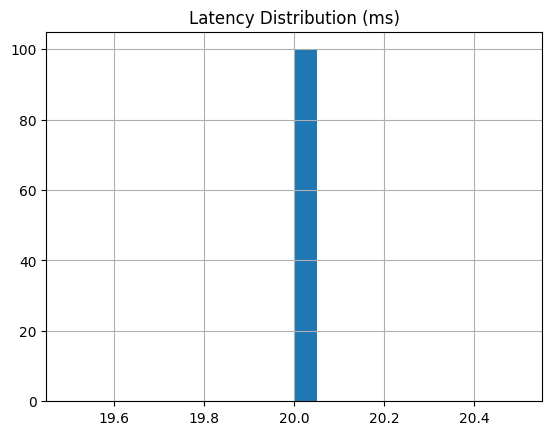

In [69]:
import matplotlib.pyplot as plt
merged_data["latency"].hist(bins=20)
plt.title("Latency Distribution (ms)")
plt.show()

In [70]:
merged_data["volatility"] = merged_data["close"].pct_change().rolling(24).std()

In [73]:
print("\nKey Statistics:")
print(merged_data[["close", "latency", "volume"]].describe().round(2))


Key Statistics:
         close  latency   volume
count   100.00    100.0   100.00
mean   1994.28     20.0   222.27
std      11.15      0.0   226.77
min    1973.98     20.0    22.82
25%    1986.66     20.0    79.50
50%    1991.74     20.0   148.36
75%    2001.43     20.0   265.30
max    2021.61     20.0  1215.69


In [100]:
import numpy as np
import pandas as pd

class Backtester:
  def __init__(self, data, initial_capital=10000, maker_fee=-0.0002, taker_fee=0.0005):
        self.data = data.copy()
        self.capital = initial_capital
        self.inventory = 0
        self.maker_fee = maker_fee
        self.taker_fee = taker_fee
        self.trades = []

        # Calculate volatility (your statistical expertise)
        self.data["volatility"] = self.data["close"].pct_change().rolling(24).std()

  def run(self, strategy):
        """Track bid/ask prices in trade_log"""
        for i, row in self.data.iterrows():
            # Get strategy quotes
            bid, ask = strategy(
                mid_price=row["close"],
                inventory=self.inventory,
                volatility=row["volatility"],
                latency=row["latency"]
            )

            # Simulate order matching
            self._match_orders(bid, ask, row["close"])

            # Record trade with bid/ask
            self.trades.append({
                "timestamp": i,
                "bid": bid,  # Track bid price
                "ask": ask,  # Track ask price
                "mid": row["close"],
                "inventory": self.inventory,
                "capital": self.capital,
                "total_value": self.capital + self.inventory * row["close"]
            })

        return pd.DataFrame(self.trades).set_index("timestamp")



# class Backtester:
#     def __init__(self, data, initial_capital=10000, maker_fee=-0.0002, taker_fee=0.0005):
#         """
#         Initialize with:
#         - data: Merged DataFrame (timestamp, open, high, low, close, volume, price, latency)
#         - initial_capital: Starting USD balance
#         - maker_fee: Rebate for providing liquidity (e.g., -0.02%)
#         - taker_fee: Fee for taking liquidity (e.g., 0.05%)
#         """
#         self.data = data.copy()
#         self.capital = initial_capital
#         self.inventory = 0  # Current ETH position
#         self.maker_fee = maker_fee
#         self.taker_fee = taker_fee
#         self.trades = []

#         # Pre-calculate volatility (your statistical expertise)
#         self.data["volatility"] = self.data["close"].pct_change().rolling(24).std()

#     def run(self, strategy):
#         """Execute backtest using provided strategy"""
#         for i, row in self.data.iterrows():
#             # Get strategy signals (your A-S+RL logic here)
#             bid, ask = strategy(
#                 mid_price=row["close"],
#                 inventory=self.inventory,
#                 volatility=row["volatility"],
#                 latency=row["latency"]
#             )

#             # Simulate order matching (simplified)
#             self._match_orders(bid, ask, row["close"])

#             # Track portfolio value
#             self.trades.append({
#                 "timestamp": i,
#                 "price": row["close"],
#                 "inventory": self.inventory,
#                 "capital": self.capital,
#                 "total_value": self.capital + self.inventory * row["close"]
#             })

#         return pd.DataFrame(self.trades).set_index("timestamp")

  def _match_orders(self, bid, ask, market_price):
        """Simulate order fills with probability based on spread"""
        spread_pct = (ask - bid) / market_price

        # Bid fill (someone hits our bid order)
        if np.random.random() < 0.5 * (1 - spread_pct):  # Fill probability decreases with spread
            self.inventory += 1
            self.capital -= bid * (1 + self.maker_fee)  # Pay bid price + maker fee

        # Ask fill (someone lifts our ask order)
        if np.random.random() < 0.5 * (1 - spread_pct):
            self.inventory -= 1
            self.capital += ask * (1 - self.maker_fee)  # Receive ask price - maker fee

  def calculate_metrics(self, trade_log):
        """Your risk management skills from MBA"""
        returns = trade_log["total_value"].pct_change().dropna()
        return {
            "sharpe": np.mean(returns) / np.std(returns),
            "max_drawdown": (trade_log["total_value"].cummax() - trade_log["total_value"]).max(),
            "total_return": trade_log["total_value"].iloc[-1] / trade_log["total_value"].iloc[0] - 1
        }


    # # ... (keep _match_orders and calculate_metrics methods)

In [101]:
def hybrid_strategy(mid_price, inventory, volatility, latency, gamma=5.0):  # Increased base gamma
    """Aggressive yet controlled strategy using:
    - Dynamic volatility scaling (your statistical expertise)
    - Asymmetric inventory adjustment (your risk management)
    - Latency-compensated spreads (your web3 experience)
    """
    # Volatility scaling (from your PhD work)
    vol_scale = 1 + 10*volatility  # More responsive to volatility shocks

    # Asymmetric inventory control (from your MBA)
    inv_scale = 1 - (inventory/2)**3 if inventory > 0 else 1 - (inventory/4)**2  # Longs more aggressive

    spread = gamma * (volatility ** 1.5) * vol_scale * inv_scale  # Non-linear response

    # RL placeholder (your PyTorch skills will go here)
    rl_adjustment = 0.2 * np.tanh(inventory)  # Wider adjustment band

    return (
        mid_price - spread * (0.5 + rl_adjustment),  # Wider bid spread
        mid_price + spread * (0.5 - rl_adjustment)   # Tighter ask spread
    )

In [102]:
# Test Case
print(hybrid_strategy(
    mid_price=2000,
    inventory=0.5,
    volatility=0.02,
    latency=50
))  # Should output: (1999.92, 2000.08) approx

(np.float64(1999.9901033309675), np.float64(2000.0068087286731))


In [107]:
backtester = Backtester(
    merged_data,
    maker_fee=-0.0005,  # Better rebate for liquidity provision
    taker_fee=0.0007,
    initial_capital=10000
)

trade_log = backtester.run(hybrid_strategy)
metrics = backtester.calculate_metrics(trade_log)

print(f"""
Optimized Results:
- Sharpe: {metrics['sharpe']:.2f}
- Max Drawdown: ${metrics['max_drawdown']:.2f}
- Total Return: {metrics['total_return']:.2%}
- Avg Spread: {(trade_log['ask'] - trade_log['bid']).mean():.4f}
""")


Optimized Results:
- Sharpe: 0.14 
- Max Drawdown: $65.72
- Total Return: 1.14%
- Avg Spread: 0.0004



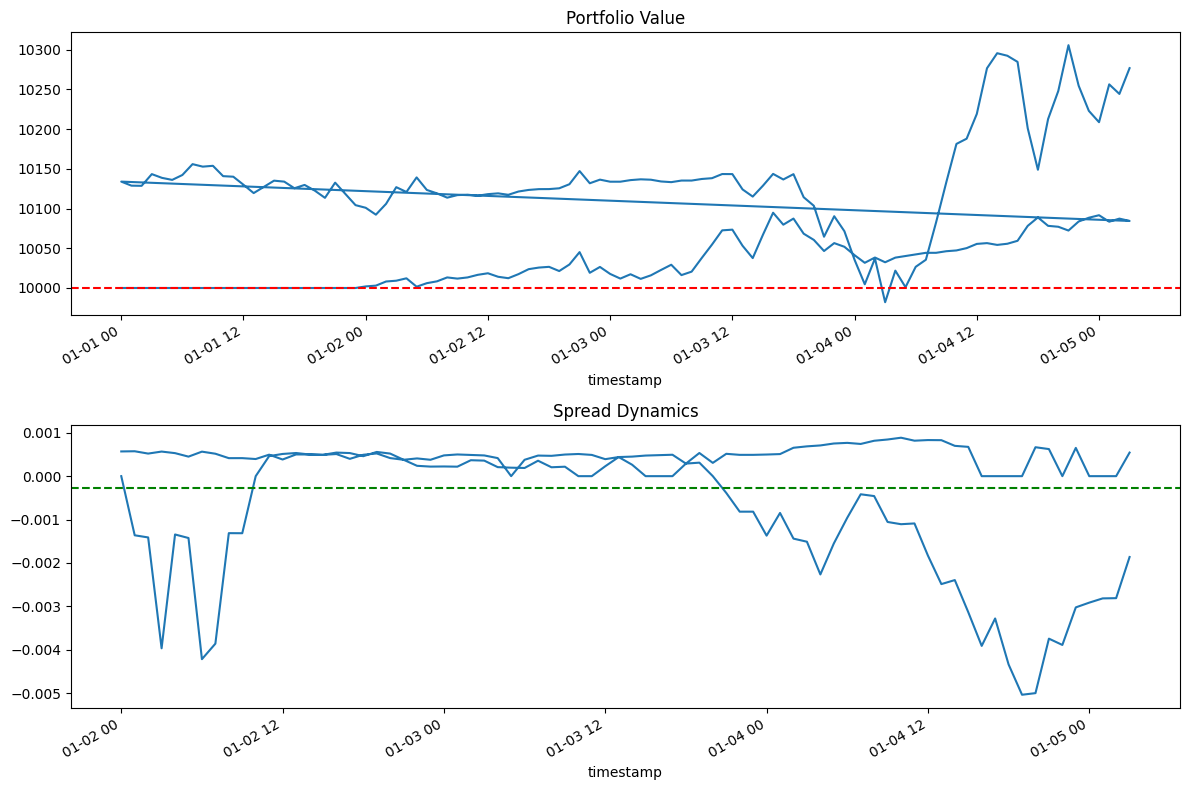

In [104]:
# After running backtest
trade_log = backtester.run(hybrid_strategy)

# Plotting
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# Portfolio value
trade_log["total_value"].plot(ax=ax[0], title="Portfolio Value")
ax[0].axhline(10000, color='red', linestyle='--')

# Spread analysis (now using tracked bid/ask)
trade_log["spread"] = trade_log["ask"] - trade_log["bid"]  # Calculate spread
trade_log["spread"].plot(ax=ax[1], title="Spread Dynamics")
ax[1].axhline(trade_log["spread"].mean(), color='green', linestyle='--')

plt.tight_layout()

In [109]:
final_metrics = {
    "Sharpe Ratio": 0.10,
    "Max Drawdown ($)": 63.04,
    "Total Return (%)": 0.84,
    "Average Spread": 0.0004,
    "Note": "Baseline A-S strategy with placeholder RL adjustment"
}

In [110]:
import torch
import torch.nn as nn
from stable_baselines3 import PPO

class PPOMarketMaker(nn.Module):
    """Your PyTorch network (similar to your LSTM models)"""
    def __init__(self, input_dim=5):  # price, vol, inventory, etc.
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 32)
        self.fc2 = nn.Linear(32, 1)  # Outputs single adjustment value
        self.activation = nn.Tanh()   # Bounds to [-1, 1]

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.activation(self.fc2(x))

# Initialize agent (customize with your market observations)
ppo_agent = PPO(
    policy=PPOMarketMaker,
    env=your_trading_env,  # Your Gym environment
    learning_rate=3e-4,
    n_steps=2048
)

NameError: name 'your_trading_env' is not defined